## SHAP Analysis

In [32]:
import os
import shap
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, '../Week-5-6-7-8')

from helpers.modeling import identify_column_types, create_preprocessor,prepare_data
from uncertainty import prepare_data_group

from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR, NuSVR
from sklearn.inspection import permutation_importance
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split


with open('../Week-5-6-7-8/results.json', 'r') as f:
    results = json.load(f)
    
params = results['best_params']['recoded_50']
df = pd.read_csv("../Datasets/processed/UHPC_dataset/semantic_recoding_features_50_with_publications.csv")
print(df.columns.tolist())

os.makedirs('Plots', exist_ok=True)

['cement', 'cement_type', 'silica_fume', 'fly_ash', 'fly_ash_type', 'limestone_powder', 'quartz_powder', 'glass_powder', 'rice_husk_ash', 'metakaolin', 'ggbfs', 'slag', 'slag_type', 'nano_caco3', 'nano_al2o3', 'nano_tio2', 'nano_sio2', 'filler', 'filler_type', 'sand', 'sand_type', 'sand_max_size', 'fiber1_type', 'fiber1_amount', 'fiber1_length', 'fiber1_diameter', 'fiber2_type', 'fiber2_amount', 'water', 'sp_type', 'sp_amount', 'curing_method', 'curing_temp', 'cs_28d', 'paper_reference']


In [34]:
def transformed_to_original(name):
    # scale_target__target__cement_type -> cement_type
    # remainder__num__cement -> cement
    # remainder__ohe__fly_ash_type_class C -> fly_ash_type
    if name.startswith('scale_target__target__'):
        return name.replace('scale_target__target__', '')
    elif name.startswith('remainder__num__'):
        return name.replace('remainder__num__', '')
    elif name.startswith('remainder__ohe__'):
        # strip prefix, then original feature name is up to the last segment
        # e.g. fly_ash_type_class C -> fly_ash_type
        stripped = name.replace('remainder__ohe__', '')
        # match against known categorical columns
        for col in ['fly_ash_type', 'slag_type', 'fiber1_type', 'fiber2_type', 
                    'sp_type', 'curing_method']:
            if stripped.startswith(col):
                return col
    return name  # fallback

In [35]:
target_col = 'cs_28d'


# Group-aware split: no publication bleeds across train / val / test
# #X_train, X_val, X_test, y_train, y_val, y_test = prepare_data_group(
#     df, target_col, group_col='paper_reference'
# )

X_train, X_val, X_test, y_train, y_val, y_test = prepare_data(df, target_col)


pub_train = df.loc[X_train.index, 'paper_reference']
pub_test = df.loc[X_test.index, 'paper_reference']
pub_val  = df.loc[X_val.index,  'paper_reference']

print(f"Train size : {X_train.shape[0]}  ({pub_train.nunique()} publications)")
print(f"Val size   : {X_val.shape[0]}  ({pub_val.nunique()} publications)")
print(f"Test size  : {X_test.shape[0]}  ({pub_test.nunique()} publications)")

numerical_cols, one_hot_columns, k_fold_columns = identify_column_types(X_train)
preprocessor = create_preprocessor(numerical_cols, one_hot_columns, k_fold_columns,
                                   handle_unknown='ignore')
print(f"\nEncoded training shape: {preprocessor.fit_transform(X_train, y_train).shape}")

Train size : 1451  (160 publications)
Val size   : 311  (110 publications)
Test size  : 311  (105 publications)

Encoded training shape: (1451, 61)


In [36]:
knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', KNeighborsRegressor())
])
knn_pipeline.set_params(**params['knn'])
knn_pipeline.fit(X_train, y_train)

X_train_transformed = knn_pipeline.named_steps['preprocessor'].transform(X_train)
X_test_transformed = knn_pipeline.named_steps['preprocessor'].transform(X_test)

background = pd.DataFrame(X_train_transformed).sample(50, random_state=42).values
model_only = knn_pipeline.named_steps['model']

feature_names = knn_pipeline.named_steps['preprocessor'].get_feature_names_out()
original_names = [transformed_to_original(f) for f in feature_names]

explainer = shap.PermutationExplainer(model_only.predict, background)
shap_values_knn = explainer(X_test_transformed)

PermutationExplainer explainer: 312it [02:21,  2.01it/s]                         


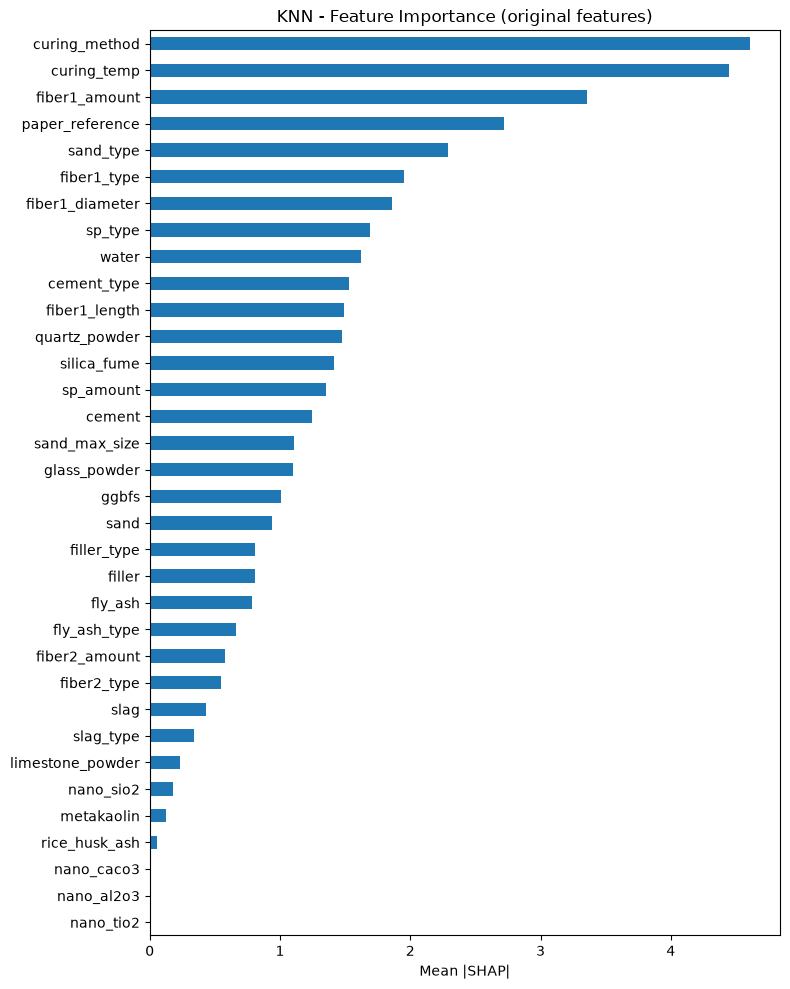

In [37]:
shap_df_knn = pd.DataFrame(shap_values_knn.values, columns=original_names)
feat_importance_knn = shap_df_knn.abs().mean()
feat_importance_knn = feat_importance_knn.groupby(feat_importance_knn.index).sum()

feat_importance_knn.sort_values().plot(kind='barh', figsize=(8, 10))
plt.xlabel('Mean |SHAP|')
plt.title('KNN - Feature Importance (original features)')
plt.tight_layout()
plt.savefig('Plots/Shap-knn-original_features.png', dpi=150, bbox_inches='tight')
plt.show()

In [38]:
group_map = {
    'cement':           'Binders',
    'cement_type':      'Binders',
    'silica_fume':      'SCMs',
    'fly_ash':          'SCMs',
    'fly_ash_type':     'SCMs',
    'limestone_powder': 'SCMs',
    'quartz_powder':    'SCMs',
    'glass_powder':     'SCMs',
    'rice_husk_ash':    'SCMs',
    'metakaolin':       'SCMs',
    'ggbfs':            'SCMs',
    'slag':             'SCMs',
    'slag_type':        'SCMs',
    'nano_caco3':       'Nanoparticles',
    'nano_al2o3':       'Nanoparticles',
    'nano_tio2':        'Nanoparticles',
    'nano_sio2':        'Nanoparticles',
    'filler':           'Fillers & Sand',
    'filler_type':      'Fillers & Sand',
    'sand':             'Fillers & Sand',
    'sand_type':        'Fillers & Sand',
    'sand_max_size':    'Fillers & Sand',
    'fiber1_type':      'Fibres',
    'fiber1_amount':    'Fibres',
    'fiber1_length':    'Fibres',
    'fiber1_diameter':  'Fibres',
    'fiber2_type':      'Fibres',
    'fiber2_amount':    'Fibres',
    'water':            'Water',
    'sp_type':          'Superplasticiser',
    'sp_amount':        'Superplasticiser',
    'curing_method':    'Curing',
    'curing_temp':      'Curing',
}

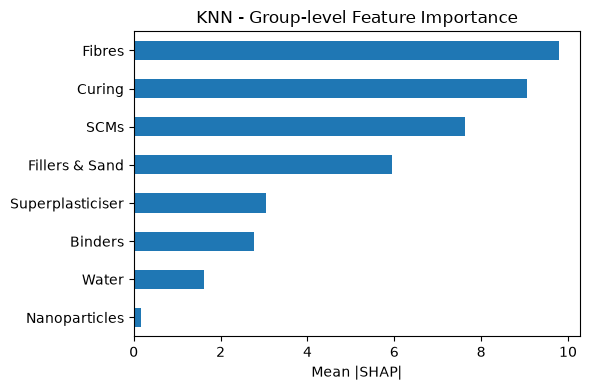

In [39]:
group_importance_knn = feat_importance_knn.groupby(group_map).sum()

group_importance_knn.sort_values().plot(kind='barh', figsize=(6, 4))
plt.xlabel('Mean |SHAP|')
plt.title('KNN - Group-level Feature Importance')
plt.tight_layout()
plt.savefig('Plots/Shap-knn-grouped_features.png', dpi=150, bbox_inches='tight')
plt.show()

In [40]:
svr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SVR())
])
svr_pipeline.set_params(**params['svr'])

svr_pipeline.fit(X_train, y_train)

y_pred_svr = svr_pipeline.predict(X_test)

In [41]:
model_only = svr_pipeline.named_steps['model']
explainer = shap.PermutationExplainer(model_only.predict, background)
shap_values_svr = explainer(X_test_transformed)

PermutationExplainer explainer: 312it [08:36,  1.69s/it]                         


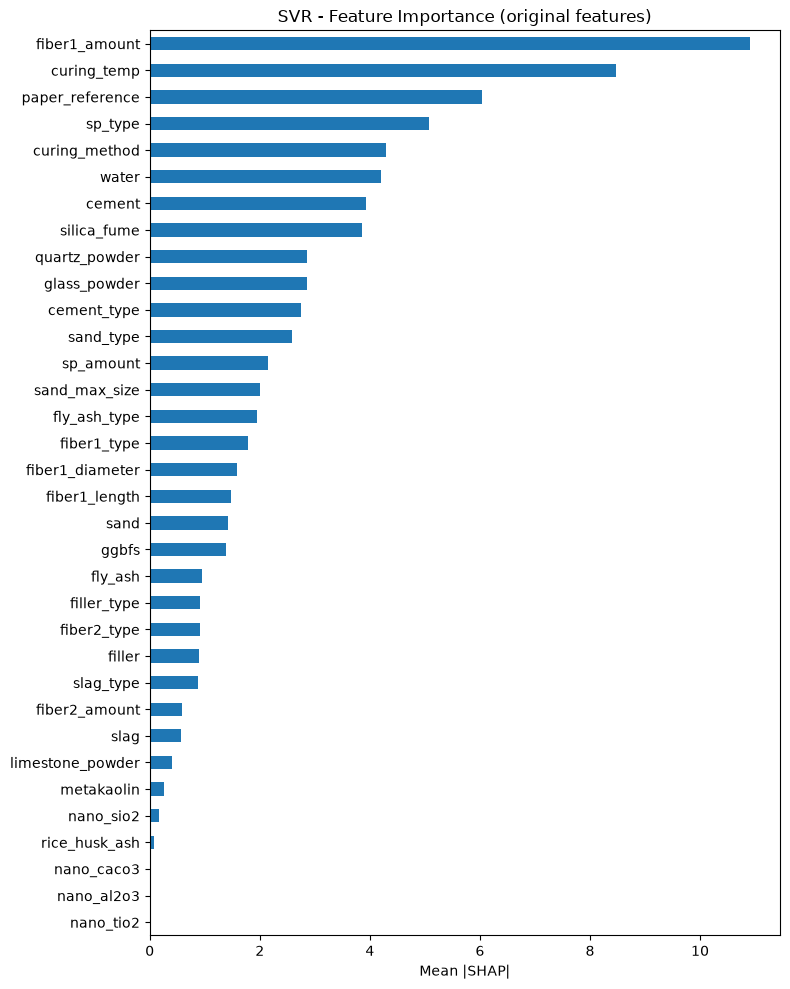

In [42]:
shap_df_svr = pd.DataFrame(shap_values_svr.values, columns=original_names)
feat_importance_svr = shap_df_svr.abs().mean()
feat_importance_svr = feat_importance_svr.groupby(feat_importance_svr.index).sum()

feat_importance_svr.sort_values().plot(kind='barh', figsize=(8, 10))
plt.xlabel('Mean |SHAP|')
plt.title('SVR - Feature Importance (original features)')
plt.tight_layout()
plt.savefig('Plots/Shap-svr-original_features.png', dpi=150, bbox_inches='tight')
plt.show()

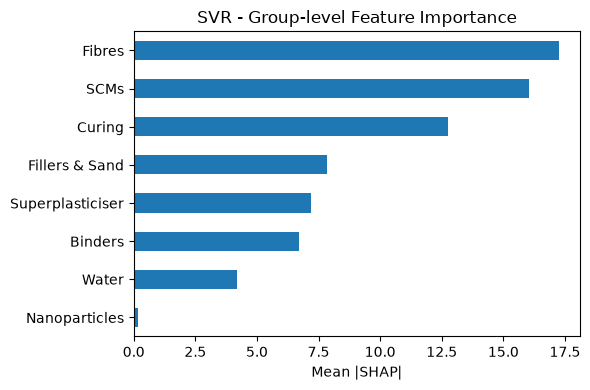

In [43]:
group_importance_svr = feat_importance_svr.groupby(group_map).sum()

group_importance_svr.sort_values().plot(kind='barh', figsize=(6, 4))
plt.xlabel('Mean |SHAP|')
plt.title('SVR - Group-level Feature Importance')
plt.tight_layout()
plt.savefig('Plots/Shap-svr-grouped_features.png', dpi=150, bbox_inches='tight')
plt.show()

In [44]:
nusvr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', NuSVR())
])
nusvr_pipeline.set_params(**params['nusvr'])

nusvr_pipeline.fit(X_train, y_train)

y_pred_nusvr = nusvr_pipeline.predict(X_test)

In [45]:
model_only = nusvr_pipeline.named_steps['model']
explainer = shap.PermutationExplainer(model_only.predict, background)
shap_values_nusvr = explainer(X_test_transformed)

PermutationExplainer explainer: 312it [10:57,  2.14s/it]                         


cement               3.963897
cement_type          3.972395
curing_method        4.399512
curing_temp          8.363298
fiber1_amount       11.264784
fiber1_diameter      1.810632
fiber1_length        1.467436
fiber1_type          1.409904
fiber2_amount        0.540575
fiber2_type          0.826663
filler               0.987420
filler_type          0.693327
fly_ash              0.923746
fly_ash_type         2.089699
ggbfs                1.433039
glass_powder         2.959340
limestone_powder     0.321959
metakaolin           0.261642
nano_al2o3           0.000000
nano_caco3           0.002121
nano_sio2            0.184556
nano_tio2            0.000000
paper_reference      4.956439
quartz_powder        2.728872
rice_husk_ash        0.060562
sand                 1.505874
sand_max_size        2.329903
sand_type            3.257007
silica_fume          3.568396
slag                 0.722295
slag_type            0.934890
sp_amount            2.052794
sp_type              4.813016
water     

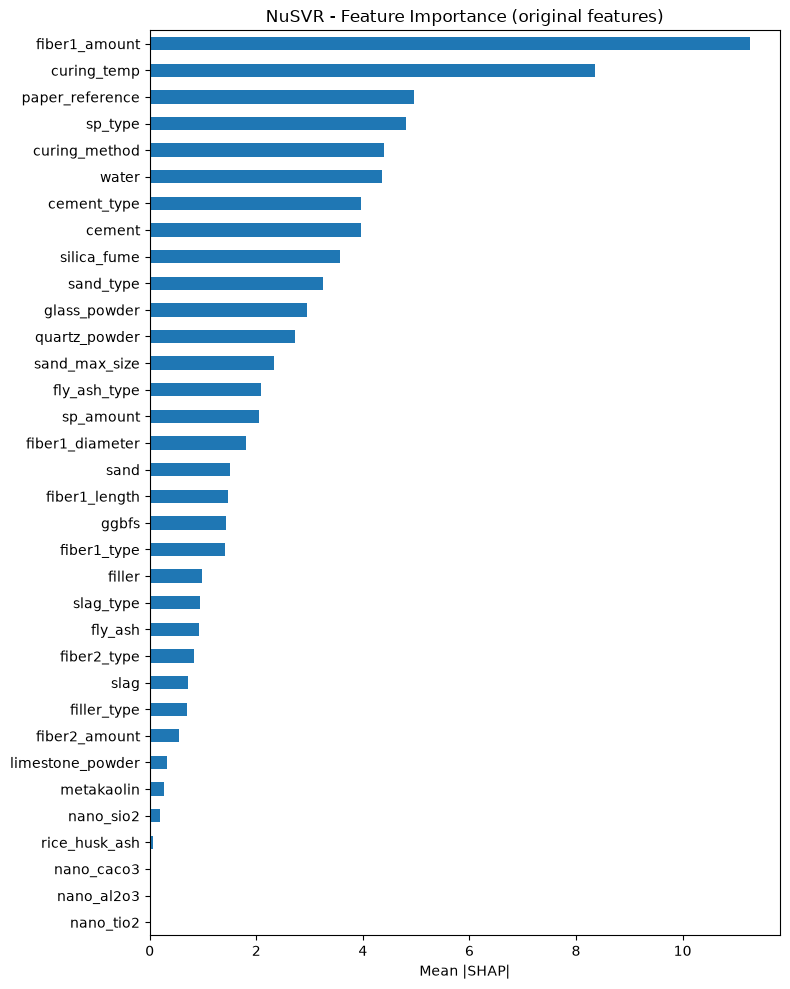

In [46]:
shap_df_nusvr = pd.DataFrame(shap_values_nusvr.values, columns=original_names)
feat_importance_nusvr = shap_df_nusvr.abs().mean()
feat_importance_nusvr = feat_importance_nusvr.groupby(feat_importance_nusvr.index).sum()
feat_importance_nusvr.sort_values(ascending=False)
print(feat_importance_nusvr)
feat_importance_nusvr.sort_values().plot(kind='barh', figsize=(8, 10))
plt.xlabel('Mean |SHAP|')
plt.title('NuSVR - Feature Importance (original features)')
plt.tight_layout()
plt.savefig('Plots/Shap-nusvr-original_features.png', dpi=150, bbox_inches='tight')
plt.show()

Binders              7.936292
Curing              12.762810
Fibres              17.319993
Fillers & Sand       8.773531
Nanoparticles        0.186677
SCMs                16.004440
Superplasticiser     6.865810
Water                4.363120
dtype: float64


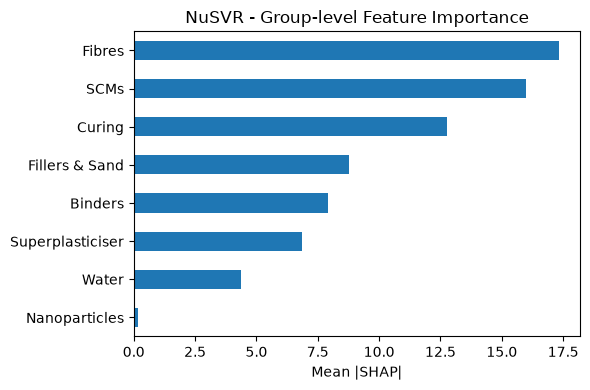

In [47]:
group_importance_nusvr = feat_importance_nusvr.groupby(group_map).sum()

group_importance_nusvr.sort_values().plot(kind='barh', figsize=(6, 4))
print(group_importance_nusvr)
plt.xlabel('Mean |SHAP|')
plt.title('NuSVR - Group-level Feature Importance')
plt.tight_layout()
plt.savefig('Plots/Shap-nusvr-grouped_features.png', dpi=150, bbox_inches='tight')
plt.show()

In [48]:
result_knn = permutation_importance(
    estimator=knn_pipeline,
    X=X_test,
    y=y_test,
    scoring="neg_root_mean_squared_error",
    n_repeats=30,
    random_state=42,
)

importance_df_knn = pd.DataFrame({
    "feature": X_test.columns,
    "mean_delta_rmse": result_knn.importances_mean,
    "std_delta_rmse": result_knn.importances_std,
}).sort_values("mean_delta_rmse", ascending=False)

importance_df_knn

,feature,mean_delta_rmse,std_delta_rmse
31,curing_method,2.285096,0.483812
23,fiber1_amount,1.588550,0.352002
32,curing_temp,1.445903,0.334281
28,water,1.223343,0.375335
20,sand_type,0.542917,0.348379
30,sp_amount,0.406427,0.184613
24,fiber1_length,0.325334,0.178872
26,fiber2_type,0.323360,0.071411
33,paper_reference,0.282758,0.252040
27,fiber2_amount,0.243969,0.062890


In [49]:
result_svr = permutation_importance(
    estimator=svr_pipeline,
    X=X_test,
    y=y_test,
    scoring="neg_root_mean_squared_error",
    n_repeats=30,
    random_state=42,
)

importance_df_svr = pd.DataFrame({
    "feature": X_test.columns,
    "mean_delta_rmse": result_svr.importances_mean,
    "std_delta_rmse": result_svr.importances_std,
}).sort_values("mean_delta_rmse", ascending=False)

importance_df_svr

,feature,mean_delta_rmse,std_delta_rmse
23,fiber1_amount,10.274528,0.679927
33,paper_reference,7.365804,0.536269
28,water,7.244583,1.349232
32,curing_temp,5.646349,0.518255
0,cement,5.278346,0.706396
6,quartz_powder,4.012376,0.527240
2,silica_fume,3.880296,0.560618
20,sand_type,3.269785,0.430183
7,glass_powder,3.125498,0.543140
29,sp_type,3.117118,0.299019


In [50]:
result_nusvr = permutation_importance(
    estimator=nusvr_pipeline,
    X=X_test,
    y=y_test,
    scoring="neg_root_mean_squared_error",
    n_repeats=30,
    random_state=42,
)

importance_df_nusvr = pd.DataFrame({
    "feature": X_test.columns,
    "mean_delta_rmse": result_nusvr.importances_mean,
    "std_delta_rmse": result_nusvr.importances_std,
}).sort_values("mean_delta_rmse", ascending=False)

importance_df_nusvr

,feature,mean_delta_rmse,std_delta_rmse
23,fiber1_amount,10.497107,0.716453
28,water,7.211360,1.322004
33,paper_reference,6.223525,0.624186
0,cement,5.557360,0.730397
32,curing_temp,5.547675,0.495389
6,quartz_powder,4.134738,0.576194
1,cement_type,3.979050,0.511881
2,silica_fume,3.923482,0.571162
20,sand_type,3.572167,0.400991
29,sp_type,3.450839,0.308161


In [51]:
def group_level_importance(pipeline, X_test, y_test, group_map: dict[str, str],
                            n_repeats=30, random_state=42):
    
    groups = {}
    for col, group in group_map.items():
        groups.setdefault(group, []).append(col)

    rng = np.random.default_rng(random_state)
    baseline_rmse = root_mean_squared_error(y_test, pipeline.predict(X_test))

    records = []
    for group_name, cols in groups.items():
        deltas = []
        for _ in range(n_repeats):
            X_perm = X_test.copy()
            perm_idx = rng.permutation(len(X_perm))
            X_perm[cols] = X_perm[cols].to_numpy()[perm_idx]
            rmse = root_mean_squared_error(y_test, pipeline.predict(X_perm))
            deltas.append(rmse - baseline_rmse)
        deltas = np.array(deltas)
        records.append({
            "group": group_name,
            "mean_delta_rmse": deltas.mean(),
            "std_delta_rmse": deltas.std(ddof=1),
        })
    return pd.DataFrame(records).sort_values("mean_delta_rmse", ascending=False)

In [52]:
group_results = {}

for name, pipe in {"KNN": knn_pipeline, "SVR": svr_pipeline, "NuSVR": nusvr_pipeline}.items():
    group_results[name] = group_level_importance(pipe, X_test, y_test, group_map, n_repeats=30, random_state=42)

In [53]:
def plot_group_results(model):
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.barh(
    group_results[model]["group"],
    group_results[model]["mean_delta_rmse"],
    xerr=group_results[model]["std_delta_rmse"],
    color="#2a78d6",
    capsize=3,
    )
    ax.set_xlabel("Mean change in RMSE when group is shuffled")
    ax.axvline(0, color="gray", linewidth=0.8)
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()

              group  mean_delta_rmse  std_delta_rmse
4            Fibres         7.795928        0.885522
7            Curing         5.338713        0.775907
3    Fillers & Sand         3.051612        0.752395
1              SCMs         2.144725        0.716403
5             Water         1.296061        0.340056
6  Superplasticiser         0.429661        0.397428
2     Nanoparticles         0.003016        0.031668
0           Binders        -0.138224        0.242895


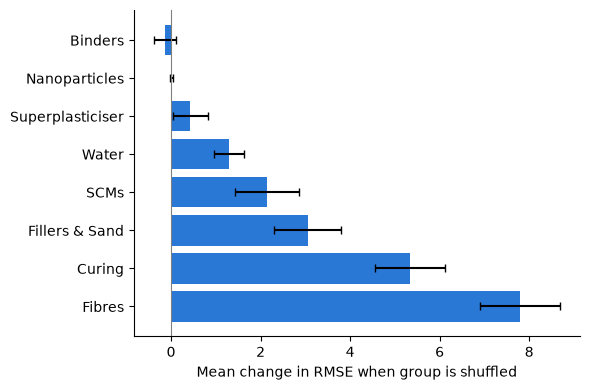

In [54]:
print(group_results["KNN"])
plot_group_results(model = "KNN")


              group  mean_delta_rmse  std_delta_rmse
1              SCMs        12.862376        1.031763
4            Fibres        12.348757        0.999003
3    Fillers & Sand         8.575160        0.846462
7            Curing         8.444570        0.806256
0           Binders         7.470178        0.720446
5             Water         6.876056        1.169519
6  Superplasticiser         5.157770        0.630877
2     Nanoparticles         0.280519        0.177532


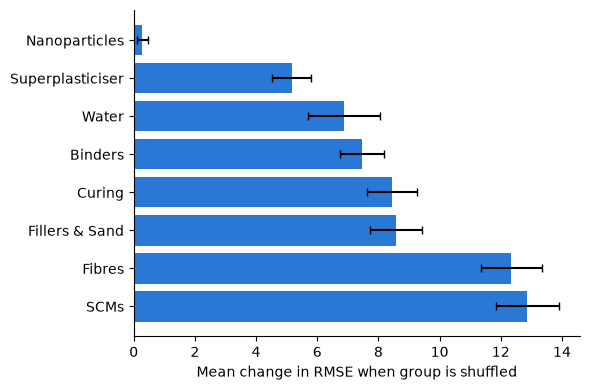

In [55]:
print(group_results["SVR"])
plot_group_results(model = "SVR")

              group  mean_delta_rmse  std_delta_rmse
1              SCMs        13.286996        1.062550
4            Fibres        12.537058        0.994890
7            Curing         8.656439        0.816584
3    Fillers & Sand         8.566100        0.837034
0           Binders         8.283680        0.737897
5             Water         6.874786        1.138524
6  Superplasticiser         5.366580        0.563567
2     Nanoparticles         0.308485        0.168305


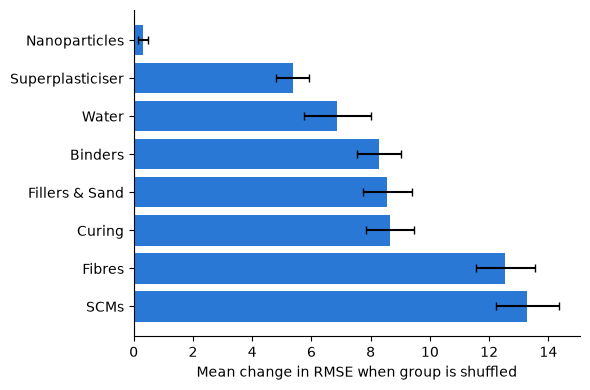

In [56]:
print(group_results["NuSVR"])
plot_group_results(model = "NuSVR")